In [6]:
#!gsutil -m cp -r gs://mask-dataset-bucket /home/jupyter/

In [1]:
import os

os.listdir('/home/jupyter/')

['mala-calidad',
 'tapabocas2.jpg',
 'mask-dataset-bucket',
 'sin-tapabocas',
 '.local',
 'retrain_pipeline.json',
 'notebook_template.ipynb',
 'tapabocas3.jpg',
 '.keras',
 '.config',
 '.gemini',
 '.npm',
 'Dockerfile',
 '.ipynb_checkpoints',
 'prueba.py',
 '.jupyter',
 '.mamba',
 '.ipython',
 '.gitignore.save',
 '.lastactive',
 'Mask-Training.ipynb',
 'storage_service.py',
 'compile_pipeline.py',
 'tapabocas',
 'input2.jsonl',
 'model_mask_covid',
 'mal-puesto',
 '.bash_history',
 '.gitignore',
 'monitor.py',
 '.wget-hsts',
 'Tapabocas-lujo',
 '__pycache__',
 'deploy.py',
 'oclusion',
 'tapabocas.jpg',
 'test.jpg',
 '.cache',
 '.git',
 'input.json',
 '.gsutil',
 'app.py',
 'tapabocas-tendencias',
 'predict.py',
 'mauro.jpg',
 'pipeline.py',
 'requirements.txt',
 '.docker',
 '.gitconfig',
 '.conda']

In [2]:
import pandas as pd
df = pd.read_csv("/home/jupyter/mask-dataset-bucket/Covid-19-PIS.v1i.multiclass/train/_classes.csv")
print(df.head())
print(df.columns.tolist())

                                            filename   with_mask  \
0     36_jpg.rf.f8cae312e521642903aebba62287cdd4.jpg           0   
1     27_jpg.rf.f9c1fe6dece8e2503e29dab3684d2edb.jpg           0   
2    233_jpg.rf.f9ca0e89c624de3cf38df7c3b79c31ab.jpg           0   
3    373_jpg.rf.f9f4e4c155c3e0092bab762f4667ce93.jpg           0   
4  48-with-mask_jpg.rf.fa1f87003e141fea4aaa692988...           1   

    without_mask  
0              1  
1              1  
2              1  
3              1  
4              0  
['filename', ' with_mask', ' without_mask']


In [3]:
base_dir = '/home/jupyter/mask-dataset-bucket/Covid-19-PIS.v1i.multiclass'

os.listdir(base_dir)

['valid', 'train', 'test', 'README.roboflow.txt', 'README.dataset.txt']

In [10]:
#print(os.listdir("/home/jupyter/mask-dataset-bucket/Covid-19-PIS.v1i.multiclass/train"))

In [11]:
#!pip install tensorflow

In [4]:
import sys
!{sys.executable} -m pip install tensorflow

In [13]:
#!{sys.executable} -m pip install scikit-learn

In [14]:
#!{sys.executable} -m pip install imutils

In [15]:
#!{sys.executable} -m pip install opencv-python

In [5]:
import tensorflow as tf
print(tf.__version__)

I0000 00:00:1781898981.305688    3304 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781898983.241192    3304 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781898987.338992    3304 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


2.21.0


In [6]:
import os
ruta = "/home/jupyter/mask-dataset-bucket/Covid-19-PIS.v1i.multiclass"
for carpeta, subcarpetas, archivos in os.walk(ruta):
    print(carpeta)

/home/jupyter/mask-dataset-bucket/Covid-19-PIS.v1i.multiclass
/home/jupyter/mask-dataset-bucket/Covid-19-PIS.v1i.multiclass/valid
/home/jupyter/mask-dataset-bucket/Covid-19-PIS.v1i.multiclass/train
/home/jupyter/mask-dataset-bucket/Covid-19-PIS.v1i.multiclass/train/.ipynb_checkpoints
/home/jupyter/mask-dataset-bucket/Covid-19-PIS.v1i.multiclass/test


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import argparse


In [8]:
import pandas as pd

data = []
labels = []

for split in ["train", "valid", "test"]:
    ruta_split = f"/home/jupyter/mask-dataset-bucket/Covid-19-PIS.v1i.multiclass/{split}"
    df = pd.read_csv(f"{ruta_split}/_classes.csv")
    
    # limpiar espacios en nombres de columnas
    df.columns = df.columns.str.strip()
    
    for _, row in df.iterrows():
        imagePath = os.path.join(ruta_split, row["filename"])
        
        if not os.path.exists(imagePath):
            continue
            
        image = load_img(imagePath, target_size=(224, 224))
        image = img_to_array(image)
        image = preprocess_input(image)
        data.append(image)
        labels.append([row["with_mask"], row["without_mask"]])

data = np.array(data, dtype="float32")
labels = np.array(labels, dtype="float32")

print(data.shape)    # (n, 224, 224, 3)
print(labels.shape)  # (n, 2)
print(np.unique(labels, axis=0))  # debe mostrar [0,1] y [1,0]

(1279, 224, 224, 3)
(1279, 2)
[[0. 1.]
 [1. 0.]]


In [9]:
(trainX, testX, trainY, testY) = train_test_split(
    data, labels,
    test_size=0.20,
    stratify=np.argmax(labels, axis=1),
    random_state=42
)

print(len(trainX))

1023


In [10]:
#construir el generador de imágenes de entrenamiento para el aumento de datos
aug = ImageDataGenerator(
	rotation_range=20,
	zoom_range=0.15,
	width_shift_range=0.2,
	height_shift_range=0.2,
	shear_range=0.15,
	horizontal_flip=True,
	fill_mode="nearest")

In [11]:
# load the MobileNetV2 network, ensuring the head FC layer sets are
# left off
baseModel = MobileNetV2(weights="imagenet", include_top=False,
	input_tensor=Input(shape=(224, 224, 3)))
# construct the head of the model that will be placed on top of the
# the base model
headModel = baseModel.output

headModel = AveragePooling2D(pool_size=(7, 7))(headModel)

headModel = Flatten(name="flatten")(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)
# place the head FC model on top of the base model (this will become
# the actual model we will train)
model = Model(inputs=baseModel.input, outputs=headModel)
# loop over all layers in the base model and freeze them so they will
# *not* be updated during the first training process
for layer in baseModel.layers:
	layer.trainable = False

/var/tmp/ipykernel_3304/1524650121.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  baseModel = MobileNetV2(weights="imagenet", include_top=False,
E0000 00:00:1781899015.033955    3304 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
import tensorflow as tf

INIT_LR = 1e-4
EPOCHS = 20
BS = 32
#opt = Adam(lr=INIT_LR, decay=INIT_LR / EPOCHS)
#opt = tf.keras.optimizers.Adam(learning_rate=INIT_LR, decay=INIT_LR / EPOCHS)
opt = tf.keras.optimizers.Adam(learning_rate=INIT_LR, beta_1=INIT_LR / EPOCHS)



model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network

H = model.fit(
	aug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS)

Epoch 1/20


I0000 00:00:1781899026.321267    3304 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


31/31 ━━━━━━━━━━━━━━━━━━━━ 36s 975ms/step - accuracy: 0.8184 - loss: 0.5115 - val_accuracy: 0.9883 - val_loss: 0.2431
Epoch 2/20
 1/31 ━━━━━━━━━━━━━━━━━━━━ 17s 570ms/step - accuracy: 0.9375 - loss: 0.2798

/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.9375 - loss: 0.2798 - val_accuracy: 0.9883 - val_loss: 0.2371
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 34s 928ms/step - accuracy: 0.9617 - loss: 0.2375 - val_accuracy: 0.9961 - val_loss: 0.1223
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 169ms/step - accuracy: 1.0000 - loss: 0.1760 - val_accuracy: 0.9961 - val_loss: 0.1199
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 29s 935ms/step - accuracy: 0.9808 - loss: 0.1378 - val_accuracy: 0.9961 - val_loss: 0.0715
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.9375 - loss: 0.1899 - val_accuracy: 0.9961 - val_loss: 0.0703
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 29s 933ms/step - accuracy: 0.9859 - loss: 0.1032 - val_accuracy: 0.9961 - val_loss: 0.0476
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - accuracy: 0.9688 - loss: 0.1259 - val_accuracy: 0.9961 - val_loss: 0.0473
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 29s 931ms/step - accuracy: 0.9899 - loss: 0.0741 - val_accuracy: 0.9961 - 

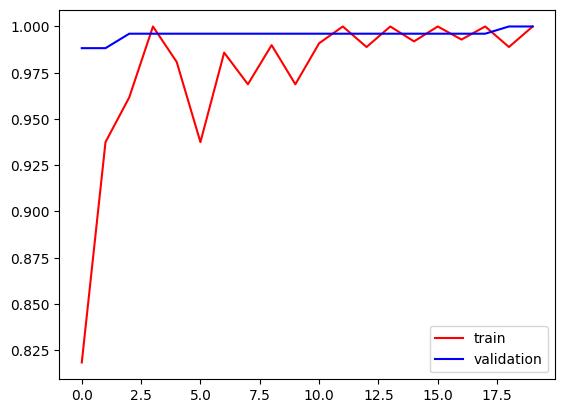

In [13]:
import matplotlib.pyplot as plt
#observamos el historial de precision a medida de cada iteracion, en datos de entrenamiento y prueba
plt.plot(H.history['accuracy'],color='red',label='train')
plt.plot(H.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

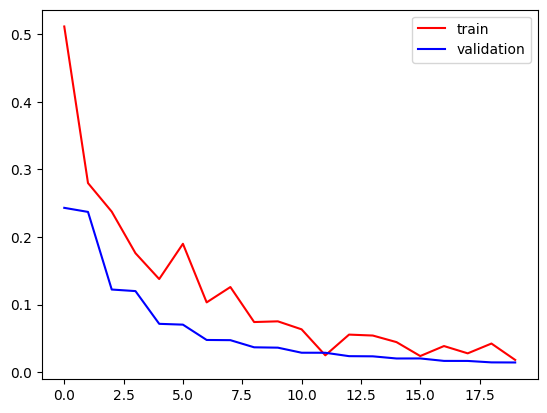

In [14]:
plt.plot(H.history['loss'],color='red',label='train')
plt.plot(H.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [15]:
predIdxs = model.predict(testX, batch_size=BS)
predIdxs = np.argmax(predIdxs, axis=1)
#print(classification_report(testY.argmax(axis=1), predIdxs,
#	target_names=lb.classes_))
print("[INFO] saving mask detector model...")
#model.save("model_mask_covid", save_format="h5")
#model.save("model_mask_covid")
#model.export("model_mask_covid")
model.save("model_mask_covid.keras")

8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 578ms/step
[INFO] saving mask detector model...


In [16]:
from google.cloud import storage

client = storage.Client()
bucket = client.bucket("ml-models-mascarilla")

blob = bucket.blob("retrain/model_mask_covid.keras")

blob.upload_from_filename("model_mask_covid.keras")

print("Modelo subido OK")

Modelo subido OK


In [ ]:
"""from google.cloud import storage

client = storage.Client()
bucket = client.bucket("mascarilla-covid-modelo")

blob = bucket.blob("uploads/tapabocas2.jpg")
blob.upload_from_filename("tapabocas2.jpg")

print("Subida OK")"""